# 01 — M2: Küçük I-JEPA eğitimi ve DINO karşılaştırması

Burada iki ölçek ayrılır:

- **Hızlı mekanizma deneyi:** sentetik görüntü, küçük ViT, CPU'da dakikalar.
- **Kaggle deneyi:** `configs/ijepa_tiny.yaml`, Imagenette-160, 30 epoch ve ablation'lar.

Hızlı deney paper sonucu değildir. Asıl öğrenme hedefi loss'un tek başına neden yeterli olmadığını; `feature std`, cosine similarity ve effective rank ile collapse'ın nasıl izlendiğini görmek.

In [9]:
from pathlib import Path
import os, sys
override = os.environ.get('JEPA_LAB_ROOT')
candidates = ([Path(override)] if override else []) + [Path.cwd(), *Path.cwd().parents, Path('/kaggle/working/jepa-study'), Path('/kaggle/working/I-JEPA'), Path('/content/jepa-study'), Path('/content/I-JEPA')]
ROOT = next((p.resolve() for p in candidates if (p / 'pyproject.toml').is_file()), None)
if ROOT is None:
    raise RuntimeError('Repo bulunamadı; JEPA_LAB_ROOT değişkenini ayarlayın.')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
print('repo:', ROOT)

repo: /kaggle/working/jepa-study


In [10]:
from pprint import pprint
import torch
from torch.utils.data import DataLoader, TensorDataset
from jepa_lab.device import seed_everything, select_device
from jepa_lab.runlog import load_yaml

seed_everything(42)
device = select_device('auto')
config = load_yaml(ROOT / 'configs/ijepa_tiny.yaml')
print('device:', device)
pprint(config)

device: cuda
{'data': {'dataset': 'imagenette-160',
          'image_size': 224,
          'root': 'data/imagenette2-160',
          'train_split': 'train',
          'validation_split': 'val'},
 'experiment': 'ijepa_tiny_imagenette',
 'mask': {'context_aspect_ratio': 1.0,
          'context_scale': [0.85, 1.0],
          'kind': 'multiblock',
          'target_aspect_ratio': [0.75, 1.5],
          'target_blocks': 4,
          'target_scale': [0.15, 0.2]},
 'model': {'architecture': 'official_vit_tiny',
           'embed_dim': 192,
           'encoder_depth': 12,
           'encoder_heads': 3,
           'patch_size': 16,
           'predictor_depth': 4,
           'predictor_dim': 192,
           'predictor_heads': 3},
 'objective': {'ema_end': 1.0,
               'ema_start': 0.996,
               'loss': 'smooth_l1',
               'normalize_target': True},
 'optimization': {'effective_batch_size': 128,
                  'learning_rate': 0.0005,
                  'optimizer': 'ada

## Tahmin 1 — Loss düşerse collapse bitmiş midir?

Tüm görüntülere aynı sabit vektörü veren encoder ile predictor düşük loss üretebilir mi? Böyle bir durumda patch feature standard deviation, örnekler arası cosine ve covariance effective rank nasıl davranır? Tahmininizi yazın.

In [11]:
from jepa_lab.metrics import measure_collapse

healthy = torch.randn(16, 64, 32)
collapsed = torch.ones(16, 64, 32)
print('healthy  :', measure_collapse(healthy))
print('collapsed:', measure_collapse(collapsed))

healthy  : CollapseMetrics(feature_std=1.0034008026123047, mean_cosine_similarity=0.00023449667787645012, effective_rank=31.462745666503906)
collapsed: CollapseMetrics(feature_std=0.0, mean_cosine_similarity=0.9999995827674866, effective_rank=1.0)


### İncele 1

Collapse tek sayı değildir. Standard deviation sıfıra yaklaşırken cosine bire yaklaşır ve effective rank çöker. Küçük veri/bütçede değerleri paper tablosuyla değil, **aynı kod ve seed'deki random encoder** ile kıyaslayın.

## 10-step hızlı mekanizma eğitimi

### Tahmin 2

İlk ve son loss'un sırası hakkında tahmin yapın. Sadece 10 adım ve rastgele görüntüler olduğu için representation kalitesi hakkında hangi iddiayı **yapamayız**?

In [12]:
from jepa_lab.image_jepa import ImageJEPA
from jepa_lab.masking import MultiBlockMasker
from jepa_lab.experiments import train_image_steps

generator = torch.Generator().manual_seed(42)
toy_images = torch.randn(128, 3, 64, 64, generator=generator)
toy_labels = torch.arange(128) % 10
toy_loader = DataLoader(TensorDataset(toy_images, toy_labels), batch_size=8, shuffle=False)
model = ImageJEPA(
    image_size=64, patch_size=8, embed_dim=64,
    encoder_depth=2, encoder_heads=4,
    predictor_dim=64, predictor_depth=2, predictor_heads=4,
)
masker = MultiBlockMasker((8, 8), num_targets=4, target_scale=(0.15, 0.20), context_scale=(0.85, 1.0))
optimizer = torch.optim.AdamW(model.trainable_parameters(), lr=1e-3)
quick_metrics = train_image_steps(
    model, toy_loader, masker, optimizer, steps=10, device=device,
    ema_start=0.996, ema_end=1.0, seed=42,
)
pprint(quick_metrics.as_dict())

# Smoke koşusunun gerçekten devam ettirilebilir olduğunu da doğrula.
from jepa_lab.checkpointing import load_training_checkpoint, save_training_checkpoint
smoke_checkpoint = save_training_checkpoint(
    ROOT / 'runs/ijepa_smoke.pt', model, optimizer, step=10,
    metadata={'seed': 42, 'scope': 'M2 ten-step smoke'},
)
resume = load_training_checkpoint(smoke_checkpoint, model, optimizer)
print({'resumed_step': resume.step, 'sha256': resume.sha256, 'metadata': resume.metadata})
assert resume.step == 10 and not resume.missing_keys and not resume.unexpected_keys

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:897.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


{'effective_rank': 45.72751998901367,
 'feature_std': 0.9668375253677368,
 'final_loss': 0.41041719913482666,
 'first_loss': 0.5510032176971436,
 'mean_cosine': 0.05870876833796501,
 'mean_loss': 0.4411343842744827,
 'steps': 10.0}
{'resumed_step': 10, 'sha256': '343441c25d5559727f9bab11e824a9dfeae7a96df6d60f59e829a2729cd280b3', 'metadata': {'seed': 42, 'scope': 'M2 ten-step smoke'}}


### İncele 2

Loss gürültülü olabilir ve son adım ilk adımdan yüksek çıkabilir; bu smoke test'in başarısız olduğu anlamına gelmez. Başarı burada sonlu tensor, doğru gradient sınırı ve çalışan EMA'dır. Representation iddiası için Imagenette, random baseline, k-NN ve frozen linear probe gerekir.

## Küçük ablation: dört target, tek target ve momentum-0 teacher

### Tahmin 3

Momentum `0` target'ı her adım online encoder'a eşitler. Bu, EMA teacher'ın yavaş hedef üretme rolünü nasıl değiştirir? 20-step küçük sonuçların paper sıralamasını neden birebir üretmesini beklememeliyiz?

In [13]:
from jepa_lab.masking import RandomPatchMasker

def run_toy_ablation(name, *, targets=4, ema_start=0.996, mask_kind='multiblock', target_masking='output', seed=42):
    seed_everything(seed)
    candidate = ImageJEPA(
        image_size=64, patch_size=8, embed_dim=48, encoder_depth=1, encoder_heads=3,
        predictor_dim=48, predictor_depth=1, predictor_heads=3, target_masking=target_masking,
    )
    masker_type = MultiBlockMasker if mask_kind == 'multiblock' else RandomPatchMasker
    candidate_masker = masker_type(
        (8, 8), num_targets=targets, target_scale=(0.15, 0.20), context_scale=(0.85, 1.0)
    )
    candidate_opt = torch.optim.AdamW(candidate.trainable_parameters(), lr=1e-3)
    result = train_image_steps(
        candidate, toy_loader, candidate_masker, candidate_opt, steps=20, device=device,
        ema_start=ema_start, ema_end=ema_start, seed=seed,
    )
    return {'name': name, **result.as_dict()}

toy_ablation = [
    run_toy_ablation('four-target + EMA', targets=4, ema_start=0.996),
    run_toy_ablation('one-target + EMA', targets=1, ema_start=0.996),
    run_toy_ablation('random-patch + EMA', mask_kind='random'),
    run_toy_ablation('target input masking + EMA', target_masking='input'),
    run_toy_ablation('four-target + momentum-0', targets=4, ema_start=0.0),
]
pprint(toy_ablation)

[{'effective_rank': 38.25666046142578,
  'feature_std': 0.9884325861930847,
  'final_loss': 0.4233221113681793,
  'first_loss': 0.5319260954856873,
  'mean_cosine': 0.017894145101308823,
  'mean_loss': 0.44113714843988416,
  'name': 'four-target + EMA',
  'steps': 20.0},
 {'effective_rank': 38.2560920715332,
  'feature_std': 0.9883034229278564,
  'final_loss': 0.4247872531414032,
  'first_loss': 0.5286761522293091,
  'mean_cosine': 0.018115736544132233,
  'mean_loss': 0.4409372925758362,
  'name': 'one-target + EMA',
  'steps': 20.0},
 {'effective_rank': 38.25063705444336,
  'feature_std': 0.9884157180786133,
  'final_loss': 0.4238080680370331,
  'first_loss': 0.536527156829834,
  'mean_cosine': 0.017953526228666306,
  'mean_loss': 0.44106435328722,
  'name': 'random-patch + EMA',
  'steps': 20.0},
 {'effective_rank': 38.25798797607422,
  'feature_std': 0.9884249567985535,
  'final_loss': 0.4239944517612457,
  'first_loss': 0.531065046787262,
  'mean_cosine': 0.017908092588186264,
  'm

## Kaggle uzun koşusu — Imagenette-160

Aşağıdaki hücre **opt-in**'dir: ağı indirir ve effective batch hesabıyla 30 epoch çalıştırır. Kaggle'da önce 10-step smoke, sonra 128 görüntü/300-step overfit, en son 30 epoch baseline çalıştırın. Overfit bellek testi `128×1=128`; baseline varsayılanı `32×4=128` effective batch kullanır. Overfit OOM verirse `64×2`, baseline OOM verirse microbatch'i yarıya indirip accumulation'ı ikiye katlayın.

Bu runner, pinlenmiş upstream'in gerçek `vit_tiny`, `vit_predictor`, `MaskCollator` ve `apply_masks` bileşenlerini ayrı process'te kullanır; paper ölçeğinde reproduction değildir.

In [18]:
import subprocess
from jepa_lab.datasets import download_imagenette

RUN_IMAGENETTE_SMOKE = False
RUN_IMAGENETTE_OVERFIT = False
RUN_LONG_IMAGENETTE = True
RUN_IMAGENETTE_ABLATIONS = False

if RUN_IMAGENETTE_SMOKE or RUN_IMAGENETTE_OVERFIT or RUN_LONG_IMAGENETTE or RUN_IMAGENETTE_ABLATIONS:
    data_root = download_imagenette(ROOT / 'data')

def run_official_ijepa(name, *extra):
    command = [
        sys.executable, str(ROOT / 'scripts/official_ijepa_train.py'),
        '--device', str(device), '--data-root', str(data_root),
        '--image-size', '224', '--patch-size', '16', '--model', 'vit_tiny',
        '--predictor-dim', '192', '--predictor-depth', '4',
        '--batch-size', '32', '--gradient-accumulation', '4', '--seed', '42',
        '--checkpoint-output', str(ROOT / f'runs/{name}.pt'),
        '--summary-output', str(ROOT / f'runs/{name}.json'),
        *extra,
    ]
    subprocess.run(command, cwd=ROOT, check=True)

if RUN_IMAGENETTE_SMOKE:
    run_official_ijepa('ijepa_imagenette_smoke_10', '--steps', '10')

if RUN_IMAGENETTE_OVERFIT:
    run_official_ijepa('ijepa_overfit_128x300', '--max-images', '128', '--steps', '300')

if RUN_LONG_IMAGENETTE:
    run_official_ijepa('ijepa_baseline_30e', '--epochs', '30', '--evaluate-probes')

if RUN_IMAGENETTE_ABLATIONS:
    ablations = {
        'one_target': ('--epochs', '10', '--num-targets', '1'),
        'random_patch_mask': ('--epochs', '10', '--mask-kind', 'random-patch'),
        'target_input_masking': ('--epochs', '10', '--target-masking', 'input'),
        'zero_momentum_teacher': (
            '--epochs', '10', '--ema-start', '0', '--ema-end', '0'
        ),
    }
    for ablation_name, arguments in ablations.items():
        run_official_ijepa(f'ijepa_ablation_{ablation_name}', *arguments)

if not (RUN_IMAGENETTE_SMOKE or RUN_IMAGENETTE_OVERFIT or RUN_LONG_IMAGENETTE or RUN_IMAGENETTE_ABLATIONS):
    print('Atlandı. Kaggle GPU aşaması için istediğiniz RUN_* bayrağını açın.')

INFO:root:VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
  )
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=768, out_features=192, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
)
INFO:root:VisionTransformer(
  (patch_embed): PatchEmbed(
  

{
  "implementation": "facebookresearch/ijepa@52c1ae95d05f743e000e8f10a1f3a79b10cff048",
  "device": "cuda",
  "environment": {
    "python": "3.12.13",
    "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
    "machine": "x86_64",
    "torch": "2.10.0+cu128",
    "cuda_available": true,
    "cuda_arch_compatible": true,
    "mps_available": false,
    "recommended_device": "cuda",
    "cuda_device": "Tesla T4",
    "cuda_compute_capability": [
      7,
      5
    ],
    "torch_cuda_arch_list": [
      "sm_70",
      "sm_75",
      "sm_80",
      "sm_86",
      "sm_90",
      "sm_100",
      "sm_120"
    ],
    "cuda_vram_gib": 14.56,
    "vjepa2_ac_profile": "reduced-or-cpu-replay"
  },
  "seed": 42,
  "total_steps": 2220,
  "epochs": 30,
  "batch_size": 32,
  "gradient_accumulation": 4,
  "effective_batch_size": 128,
  "model": "vit_tiny",
  "image_size": 224,
  "patch_size": 16,
  "num_targets": 4,
  "mask_kind": "multiblock",
  "target_masking": "output",
  "ema": [
    0.996,
 

## k-NN ve frozen linear probe sonucu

Aynı train/validation split ve seed ile hem eğitilmiş encoder hem de aynı mimaride random encoder için çalıştırın. Kabul ölçütü: eğitilmiş modelin k-NN/linear sonucu random encoder'dan en az 5 yüzde puan yüksek.

In [19]:
import json

baseline_summary = ROOT / 'runs/ijepa_baseline_30e.json'
if baseline_summary.is_file():
    baseline_result = json.loads(baseline_summary.read_text())
    pprint(baseline_result['representation_evaluation'])
else:
    print('30-epoch resmî runner --evaluate-probes ile trained/random sonucu aynı JSON dosyasına yazar.')

{'absolute_deltas': {'knn': 0.06038215756416321, 'linear': 0.10343948006629944},
 'criterion': 'either k-NN or frozen-linear delta is at least 0.05',
 'passes_plus_5_points': True,
 'random': {'knn_accuracy': 0.31133759021759033,
            'linear_accuracy': 0.35643312335014343,
            'majority_baseline': 0.10675159096717834},
 'trained': {'knn_accuracy': 0.37171974778175354,
             'linear_accuracy': 0.45987260341644287,
             'majority_baseline': 0.10675159096717834}}


## k-NN kararını görsel olarak incele

Önce global k-NN/linear sonuçlarını grafikleştireceğiz. Sonra kaydedilmiş baseline checkpoint'ini yükleyip yeniden eğitim yapmadan train/validation feature'larını çıkaracağız. Bir doğru ve bir yanlış validation örneği için en yakın 20 train görüntüsü, sınıf oyları ve linear-probe olasılıkları kaydedilecek.

> Aşağıda gösterilen crop/renk/occlusion görünümleri görsel inceleme içindir; global accuracy hesabında evaluation preprocessing yalnız resize + center-crop kullanır.

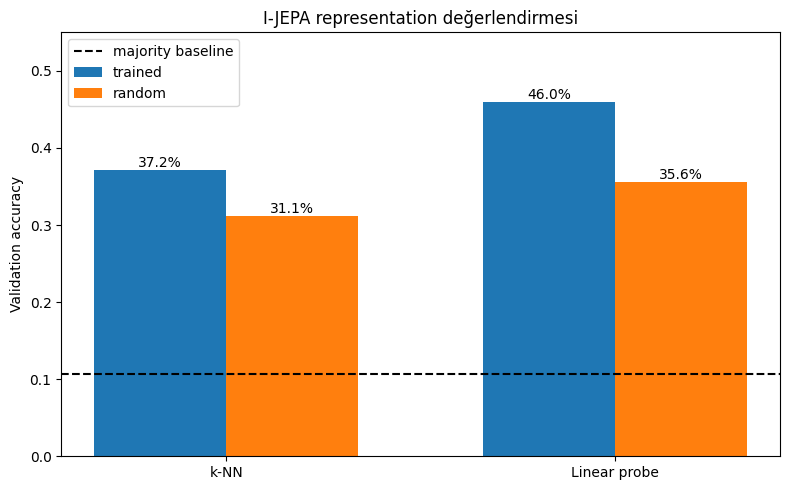

In [20]:
import numpy as np
import matplotlib.pyplot as plt

evaluation = baseline_result['representation_evaluation']
methods = ['k-NN', 'Linear probe']
trained_scores = [
    evaluation['trained']['knn_accuracy'],
    evaluation['trained']['linear_accuracy'],
]
random_scores = [
    evaluation['random']['knn_accuracy'],
    evaluation['random']['linear_accuracy'],
]
majority = evaluation['trained']['majority_baseline']
positions = np.arange(len(methods))
width = 0.34

figure, axis = plt.subplots(figsize=(8, 5))
trained_bars = axis.bar(positions - width / 2, trained_scores, width, label='trained')
random_bars = axis.bar(positions + width / 2, random_scores, width, label='random')
axis.axhline(majority, color='black', linestyle='--', label='majority baseline')
axis.set_xticks(positions, methods)
axis.set_ylim(0, 0.55)
axis.set_ylabel('Validation accuracy')
axis.set_title('I-JEPA representation değerlendirmesi')
axis.legend()
axis.bar_label(trained_bars, labels=[f'{value:.1%}' for value in trained_scores])
axis.bar_label(random_bars, labels=[f'{value:.1%}' for value in random_scores])
figure.tight_layout()
plt.show()

In [21]:
# Yeniden eğitim yoktur; checkpoint'ten feature çıkarımı ve probe analizi yapılır.
knn_examples_path = ROOT / 'runs' / 'ijepa_baseline_30e_knn_examples.npz'
baseline_checkpoint = ROOT / 'runs' / 'ijepa_baseline_30e.pt'
assert baseline_checkpoint.is_file(), baseline_checkpoint

subprocess.run([
    sys.executable, str(ROOT / 'scripts/official_ijepa_knn_examples.py'),
    '--device', str(device),
    '--data-root', str(data_root),
    '--checkpoint', str(baseline_checkpoint),
    '--model', 'vit_tiny',
    '--image-size', '224',
    '--patch-size', '16',
    '--predictor-dim', '192',
    '--predictor-depth', '4',
    '--batch-size', '128',
    '--k', '20',
    '--output', str(knn_examples_path),
], cwd=ROOT, check=True)

/usr/bin/python3: can't open file '/kaggle/working/jepa-study/scripts/official_ijepa_knn_examples.py': [Errno 2] No such file or directory


CalledProcessError: Command '['/usr/bin/python3', '/kaggle/working/jepa-study/scripts/official_ijepa_knn_examples.py', '--device', 'cuda', '--data-root', '/kaggle/working/jepa-study/data/imagenette2-160', '--checkpoint', '/kaggle/working/jepa-study/runs/ijepa_baseline_30e.pt', '--model', 'vit_tiny', '--image-size', '224', '--patch-size', '16', '--predictor-dim', '192', '--predictor-depth', '4', '--batch-size', '128', '--k', '20', '--output', '/kaggle/working/jepa-study/runs/ijepa_baseline_30e_knn_examples.npz']' returned non-zero exit status 2.

In [ ]:
with np.load(knn_examples_path, allow_pickle=False) as archive:
    knn_examples = {name: archive[name].copy() for name in archive.files}

imagenette_names = {
    'n01440764': 'tench',
    'n02102040': 'English springer',
    'n02979186': 'cassette player',
    'n03000684': 'chain saw',
    'n03028079': 'church',
    'n03394916': 'French horn',
    'n03417042': 'garbage truck',
    'n03425413': 'gas pump',
    'n03445777': 'golf ball',
    'n03888257': 'parachute',
}
class_names = [imagenette_names.get(name, name) for name in knn_examples['class_names']]
print('Hazır örnekler:', knn_examples['example_kind'].tolist())
print('Değiştirilebilir seçim: EXAMPLE_KIND = "correct" veya "incorrect"')

In [ ]:
from PIL import Image
from jepa_lab.stimuli import image_views

EXAMPLE_KIND = 'incorrect'  # 'correct' yapıp hücreyi tekrar çalıştırabilirsiniz.
example_position = knn_examples['example_kind'].tolist().index(EXAMPLE_KIND)
true_label = int(knn_examples['query_labels'][example_position])
knn_prediction = int(knn_examples['knn_predictions'][example_position])
linear_prediction = int(knn_examples['linear_predictions'][example_position])
linear_confidence = float(knn_examples['linear_confidence'][example_position])
query_path = str(knn_examples['query_paths'][example_position])
neighbour_paths = knn_examples['neighbour_paths'][example_position]
neighbour_labels = knn_examples['neighbour_labels'][example_position].astype(int)
neighbour_similarities = knn_examples['neighbour_similarities'][example_position]

figure = plt.figure(figsize=(17, 10))
grid = figure.add_gridspec(4, 6, width_ratios=[1.7, 1, 1, 1, 1, 1])
query_axis = figure.add_subplot(grid[:, 0])
query_axis.imshow(Image.open(query_path).convert('RGB'))
query_axis.set_title(
    f'Validation sorgusu ({EXAMPLE_KIND})\n'
    f'Gerçek: {class_names[true_label]}\n'
    f'k-NN: {class_names[knn_prediction]}\n'
    f'Linear: {class_names[linear_prediction]} ({linear_confidence:.1%})'
)
query_axis.axis('off')

for rank, (path, label, similarity_value) in enumerate(
    zip(neighbour_paths, neighbour_labels, neighbour_similarities), start=1
):
    row, column = divmod(rank - 1, 5)
    axis = figure.add_subplot(grid[row, column + 1])
    axis.imshow(Image.open(str(path)).convert('RGB'))
    matches = label == true_label
    marker = '✓' if matches else '×'
    axis.set_title(
        f'{rank}. {marker} {class_names[label]}\ncos={similarity_value:.3f}',
        color='forestgreen' if matches else 'crimson',
        fontsize=9,
    )
    axis.axis('off')

figure.suptitle('Validation görüntüsü ve cosine ile en yakın 20 train komşusu')
figure.tight_layout()
plt.show()

vote_counts = np.bincount(neighbour_labels, minlength=len(class_names))
linear_probabilities = knn_examples['linear_probabilities'][example_position]
figure, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(class_names, vote_counts)
axes[0].set_xlim(0, 20)
axes[0].set_xlabel('20 komşu içindeki oy sayısı')
axes[0].set_title(f'k-NN kararı: {class_names[knn_prediction]}')
axes[1].barh(class_names, linear_probabilities)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Softmax olasılığı')
axes[1].set_title(f'Linear-probe kararı: {class_names[linear_prediction]}')
for axis in axes:
    axis.invert_yaxis()
figure.tight_layout()
plt.show()

query_views = image_views(query_path, image_size=224)
figure, axes = plt.subplots(1, 4, figsize=(14, 4))
for axis, (name, pixels) in zip(axes, query_views.items()):
    axis.imshow(pixels.permute(1, 2, 0))
    axis.set_title(name)
    axis.axis('off')
figure.suptitle('Seçilen validation görüntüsünün kontrollü görünümleri')
figure.tight_layout()
plt.show()

## DINO karşılaştırması — resmî frozen ViT-S/16

DINO burada JEPA değildir ve sıfırdan eğitilmez. İki resmî script ortak `shared-image-scene-v1` görüntüsünü ve aynı crop/renk/occlusion dönüşümlerini kullanır; yalnız her modelin kendi preprocessing'i uygulanır. Hücre DINO'yu indirir ve yerel I-JEPA checkpoint'ini ister; bayrak kapalıyken çalışmaz.

### Tahmin 4

DINO'nun view-invariance objective'i crop/renk dönüşümlerine neden güçlü olabilir? I-JEPA'nın predictor'ı ise target konumunu neden bilmek zorundadır?

In [ ]:
RUN_DINO_IJEPA_VIEWS = False
if RUN_DINO_IJEPA_VIEWS:
    ijepa_checkpoint = ROOT / 'checkpoints/IN1K-vit.h.14-300e.pth.tar'
    if not ijepa_checkpoint.is_file():
        raise FileNotFoundError('Önce resmî I-JEPA ViT-H/14 checkpointini indirin.')
    subprocess.run([
        sys.executable, str(ROOT / 'scripts/official_ijepa_features.py'),
        '--device', str(device), '--model', 'vit_huge', '--patch-size', '14',
        '--image-size', '224', '--checkpoint', str(ijepa_checkpoint),
        '--output', str(ROOT / 'runs/ijepa_views.npz'),
    ], cwd=ROOT, check=True)
    subprocess.run([
        sys.executable, str(ROOT / 'scripts/official_dino_features.py'),
        '--device', str(device), '--image-size', '224',
        '--output', str(ROOT / 'runs/dino_views.npz'),
    ], cwd=ROOT, check=True)
    from jepa_lab.evaluation import temporal_perturbation_summary
    pprint({
        'I-JEPA': temporal_perturbation_summary(ROOT / 'runs/ijepa_views.npz').as_dict(),
        'DINO': temporal_perturbation_summary(ROOT / 'runs/dino_views.npz').as_dict(),
    })
else:
    print('Atlandı. Checkpoint ve ağ erişimi hazır olduğunda RUN_DINO_IJEPA_VIEWS=True yapın.')

## M2 geçiş kontrolü

- DINO: iki view arasındaki temsil eşleşmesi; I-JEPA: context'ten konuma koşullu target latent prediction.
- Düşük loss tek başına collapse olmadığını kanıtlamaz.
- Ablation'lar aynı veri/seed/step bütçesiyle kıyaslanır.
- Küçük koşunun paper sıralamasını üretmemesi veri, model ve bütçe farkıyla açıklanır.
- Sonraki aşamaya geçmek için k-NN veya frozen linear probe'da random encoder'a göre ≥5 puan farkı gerçek Imagenette koşusunda göstermelisiniz.